In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


<Axes: xlabel='age', ylabel='Count'>

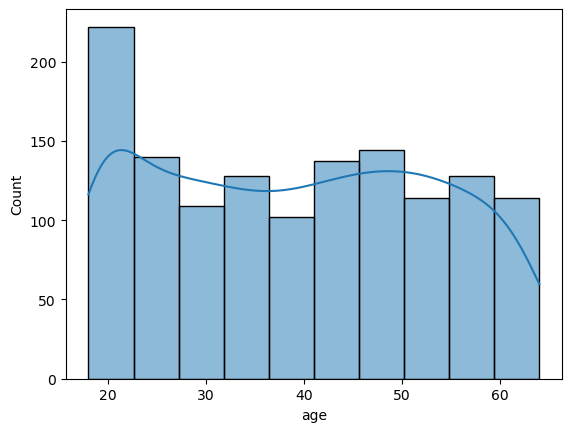

In [7]:
sns.histplot(data=df,x = "age",kde=True,bins=10)

<Axes: xlabel='bmi', ylabel='Count'>

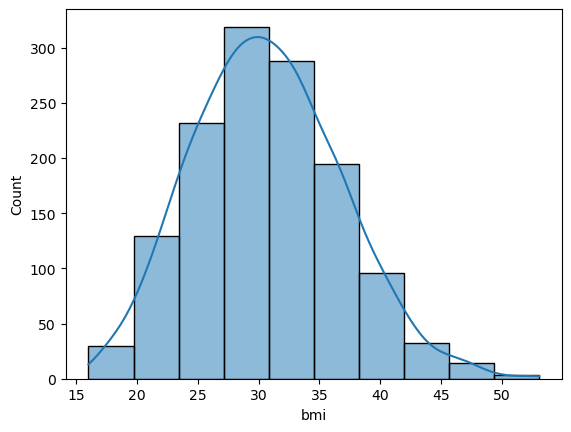

In [8]:
sns.histplot(data=df,x = "bmi",kde=True,bins=10)

<Axes: xlabel='children', ylabel='Count'>

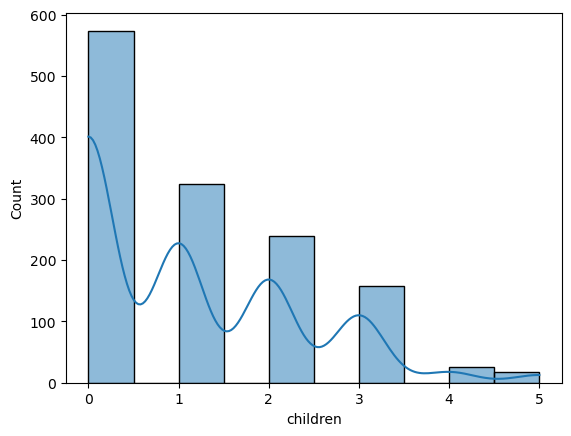

In [9]:
sns.histplot(data=df,x = "children",kde=True,bins=10)

<Axes: xlabel='children', ylabel='expenses'>

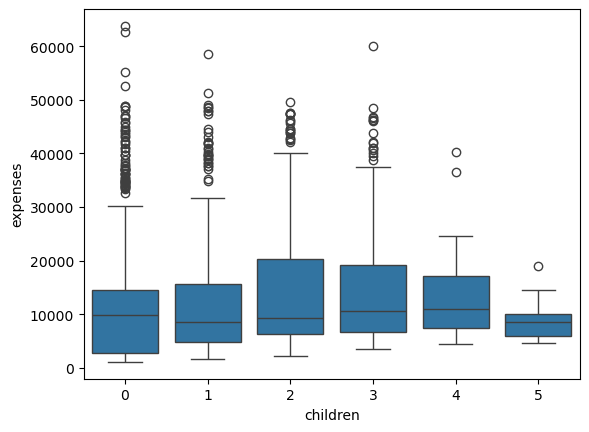

In [10]:
sns.boxplot(data=df,x = "children",y = "expenses")

<Axes: xlabel='smoker', ylabel='expenses'>

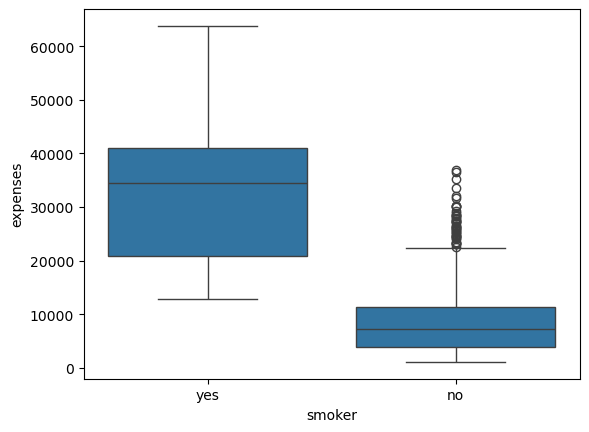

In [11]:
sns.boxplot(data=df,x = "smoker",y = "expenses")

<Axes: xlabel='region', ylabel='expenses'>

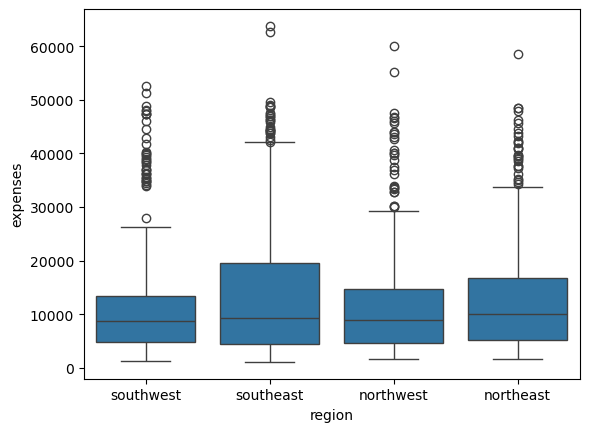

In [12]:
sns.boxplot(data=df,x = "region",y = "expenses")

<Axes: xlabel='sex', ylabel='count'>

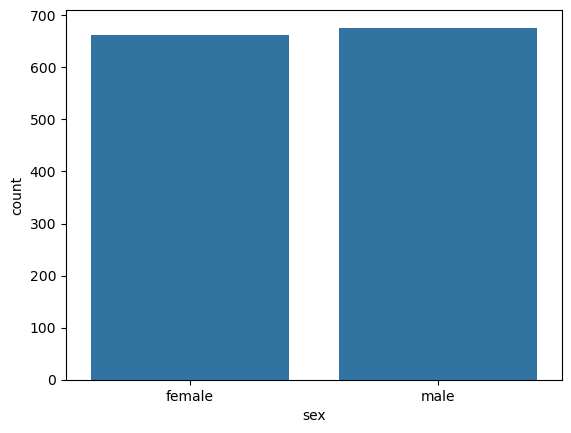

In [13]:
sns.countplot(data=df,x="sex")

In [14]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(1)

In [18]:
df = df.drop_duplicates()

<Axes: >

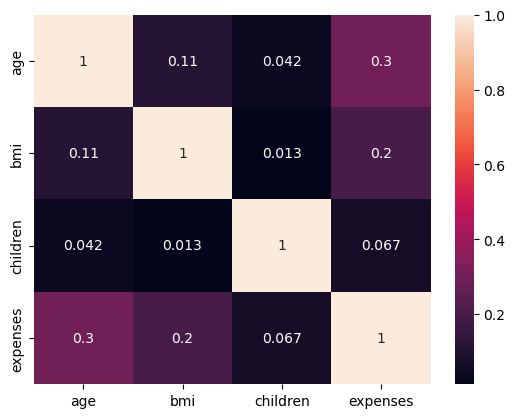

In [20]:
sns.heatmap(df.corr(numeric_only=True),annot=True,)

In [24]:
# Select the columns for train
x = df[["age"]]
y = df["expenses"]


In [25]:
# data split into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=25)

In [26]:
y_train.shape

(1069,)

In [28]:
y_test.shape

(268,)

In [29]:
# call the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
# Train the model

In [30]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
model.coef_

array([242.56517177])

In [32]:
model.intercept_

np.float64(3769.4369646856703)

In [34]:
#prdict value
y_pred = model.predict(x_test)
y_pred

array([15170.00003801, 16140.26072511, 15412.56520979, 14442.30452269,
       16140.26072511,  8135.6100566 , 13957.17417915, 14684.86969447,
       17838.21692752, 12259.21797674, 11531.52246142, 14442.30452269,
        8378.17522837, 13957.17417915, 12016.65280497, 12986.91349206,
        9348.43591546, 16625.39106865,  8863.30557192, 10318.69660255,
       15412.56520979, 10561.26177433, 12016.65280497, 17838.21692752,
       17110.5214122 , 14927.43486624, 15412.56520979, 14199.73935092,
        8620.74040014, 19293.60795815, 15170.00003801,  8378.17522837,
       11046.39211787, 13714.60900738, 17595.65175574, 17353.08658397,
       17838.21692752, 10076.13143078, 15170.00003801, 17595.65175574,
        9105.87074369, 14199.73935092,  8620.74040014, 12744.34832028,
       13714.60900738,  9348.43591546, 10318.69660255, 19293.60795815,
       16140.26072511,  8135.6100566 ,  8135.6100566 , 16140.26072511,
       13472.0438356 , 16140.26072511, 14442.30452269, 15412.56520979,
      

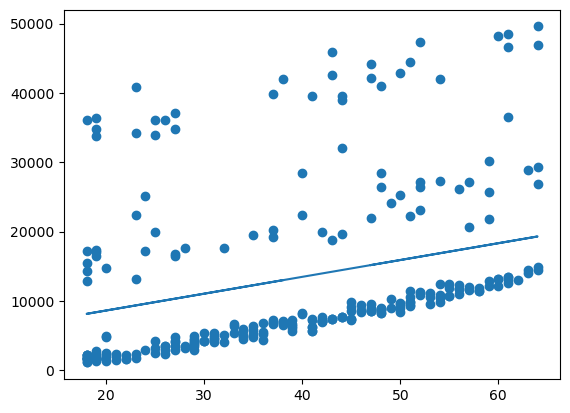

In [35]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)

In [36]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

9116.657516733074
128861058.65267788
0.12593246349669673


In [42]:
x = df.drop("expenses",axis=1)
x = pd.get_dummies(x)

y = df["expenses"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)
model = LinearRegression()
model.fit(x_train,y_train)
y_model=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

9191.673889758791
142387349.38529605
-0.10070760358079345
[   255.87527961    387.07353479    579.99448853    260.9063593
   -260.9063593  -11795.15155659  11795.15155659    676.30592343
    207.85216909   -682.30089901   -201.85719351]
-2270.07816495304


In [43]:
age=20,
bmi=28,
sex = male,
smokers=yes,
region=northeast,children=2

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.9,0,True,False,False,True,False,False,False,True
1,18,33.8,1,False,True,True,False,False,False,True,False
2,28,33.0,3,False,True,True,False,False,False,True,False
3,33,22.7,0,False,True,True,False,False,True,False,False
4,32,28.9,0,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,31.0,3,False,True,True,False,False,True,False,False
1334,18,31.9,0,True,False,True,False,True,False,False,False
1335,18,36.9,0,True,False,True,False,False,False,True,False
1336,21,25.8,0,True,False,True,False,False,False,False,True


In [50]:
model.predict(np.array([[20,28,2,0,1,0,1,1,0,0,1]]))



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26854.16930551])

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

df=pd.read_csv('dataset/Fish.csv')
df
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

df=pd.read_csv('dataset/insurance.csv')
x=df.drop(['expenses','region'],axis=1)
x=pd.get_dummies(x)
y=df['expenses']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/Fish.csv'